# SignBridge - Dataset Exploration & Preprocessing

In [ ]:
## Step 1: Core Statistics
from pathlib import Path
import pandas as pd

DATA_PATH = Path('..') / 'data' / 'how2sign_realigned_train.csv'

required_cols = [
    'VIDEO_ID',
    'VIDEO_NAME',
    'SENTENCE_ID',
    'SENTENCE_NAME',
    'START_REALIGNED',
    'END_REALIGNED',
    'SENTENCE',
]

df = pd.read_csv(DATA_PATH, sep='\t')
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns: {missing_cols}')

df['START_REALIGNED'] = pd.to_numeric(df['START_REALIGNED'], errors='coerce')
df['END_REALIGNED'] = pd.to_numeric(df['END_REALIGNED'], errors='coerce')

df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = (
    df['SENTENCE']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.split()
    .str.len()
)
df['char_count'] = df['SENTENCE'].fillna('').astype(str).str.len()

valid_duration = df['duration_sec'].dropna()
valid_words = df['word_count'].dropna()

summary = {
    'num_examples': len(df),
    'unique_videos': df['VIDEO_ID'].nunique(),
    'unique_sentences': df['SENTENCE_ID'].nunique(),
    'duplicate_sentence_ids': int(df.duplicated(subset=['SENTENCE_ID']).sum()),
    'missing_sentences': int(df['SENTENCE'].isna().sum()),
    'non_positive_duration_rows': int((df['duration_sec'] <= 0).sum()),
    'total_duration_hours': float(valid_duration.sum() / 3600.0),
    'avg_duration_sec': float(valid_duration.mean()),
    'median_duration_sec': float(valid_duration.median()),
    'p90_duration_sec': float(valid_duration.quantile(0.90)),
    'avg_word_count': float(valid_words.mean()),
    'median_word_count': float(valid_words.median()),
    'p90_word_count': float(valid_words.quantile(0.90)),
}

print('How2Sign realigned train - core stats')
print('-' * 44)
for k, v in summary.items():
    if isinstance(v, float):
        print(f'{k:28s}: {v:.3f}')
    else:
        print(f'{k:28s}: {v}')

print('\nDuration statistics (sec):')
print(valid_duration.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print('\nWord-count statistics:')
print(valid_words.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

print('\nTop 5 longest examples by duration:')
display(
    df.sort_values('duration_sec', ascending=False)[
        ['VIDEO_ID', 'SENTENCE_ID', 'START_REALIGNED', 'END_REALIGNED', 'duration_sec', 'word_count', 'SENTENCE']
    ].head(5)
)


How2Sign realigned train - core stats
--------------------------------------------
num_examples                : 31165
unique_videos               : 2192
unique_sentences            : 30932
duplicate_sentence_ids      : 233
missing_sentences           : 0
non_positive_duration_rows  : 0
total_duration_hours        : 59.331
avg_duration_sec            : 6.854
median_duration_sec         : 5.270
p90_duration_sec            : 13.610
avg_word_count              : 17.659
median_word_count           : 15.000
p90_word_count              : 33.000

Duration statistics (sec):
count    31165.000000
mean         6.853542
std          6.325943
min          0.010000
10%          1.670000
25%          2.990000
50%          5.270000
75%          8.800000
90%         13.610000
95%         17.630000
99%         28.513600
max        143.030000
Name: duration_sec, dtype: float64

Word-count statistics:
count    31165.000000
mean        17.659394
std         12.636150
min          1.000000
10%          5.0

,VIDEO_ID,SENTENCE_ID,START_REALIGNED,END_REALIGNED,duration_sec,word_count,SENTENCE
24247,FIbFH_Tdnb8,FIbFH_Tdnb8_2,14.77,157.80,143.03,19,"So I'm going to show it to you a few times, an..."
3127,05svBr3FJD4,05svBr3FJD4_1,0.75,124.30,123.55,195,This one is called X marks the spot and it's a...
9123,1LEWQlRiIDg,1LEWQlRiIDg_10,0.85,124.00,123.15,24,And women were considered to be better than me...
8857,1IHiA_6XXrI,1IHiA_6XXrI_12,1.97,124.59,122.62,11,They're kind of like big poofy baggy pants for...
605,-916rCqIrfY,-916rCqIrfY_20,107.00,228.56,121.56,17,"But, I think it's a great way to kick, bring i..."


In [ ]:
## Step 2: Clip-to-Annotation Matching

from pathlib import Path
import pandas as pd

CLIPS_DIR = Path(r'D:\How2Sign\train\train_rgb_front_clips')
if 'df' not in globals():
    df = pd.read_csv(Path('..') / 'data' / 'how2sign_realigned_train.csv', sep='\t')

sentence_names = set(df['SENTENCE_NAME'].astype(str).tolist())
clip_files = [p for p in CLIPS_DIR.glob('*.mp4')]
clip_names = set(p.stem for p in clip_files)

matched = sentence_names & clip_names
missing_clips = sentence_names - clip_names
extra_files = clip_names - sentence_names

print('Clip-to-annotation matching')
print('-' * 32)
print(f'Total annotations (sentences): {len(sentence_names)}')
print(f'Total clip files: {len(clip_names)}')
print(f'Matched: {len(matched)}')
print(f'Missing clips: {len(missing_clips)}')
print(f'Unmatched clip files (no annotation): {len(extra_files)}')

if missing_clips:
    print('\nSample missing clips (up to 10):')
    for name in list(sorted(missing_clips))[:10]:
        print(f'  {name}')

if extra_files:
    print('\nSample extra clip files (up to 10):')
    for name in list(sorted(extra_files))[:10]:
        print(f'  {name}')


Clip-to-annotation matching
--------------------------------
Total annotations (sentences): 31165
Total clip files: 31047
Matched: 31047
Missing clips: 118
Unmatched clip files (no annotation): 0

Sample missing clips (up to 10):
  -b44ieHORm4_8-5-rgb_front
  006DXpJ9erw_8-5-rgb_front
  08JotxFsA4Y_11-5-rgb_front
  09KiqMdCSKc_22-8-rgb_front
  0E4mKYwAhOs_8-8-rgb_front
  0Esq_TAc-1Y_19-5-rgb_front
  0Esq_TAc-1Y_20-5-rgb_front
  0Esq_TAc-1Y_21-5-rgb_front
  0Esq_TAc-1Y_22-5-rgb_front
  0Esq_TAc-1Y_23-5-rgb_front


In [ ]:
## Step 3: Drop Annotations with Missing Clips

from pathlib import Path
import pandas as pd

DATA_PATH = Path('..') / 'data' / 'how2sign_realigned_train.csv'
FILTERED_OUT = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'
MISSING_OUT = Path('..') / 'data' / 'how2sign_missing_clips.csv'

if 'df' not in globals():
    df = pd.read_csv(DATA_PATH, sep='\t')

CLIPS_DIR = Path(r'D:\How2Sign\train\train_rgb_front_clips')
clip_names = set(p.stem for p in CLIPS_DIR.glob('*.mp4'))

missing_mask = ~df['SENTENCE_NAME'].astype(str).isin(clip_names)
missing_df = df[missing_mask].copy()
filtered_df = df[~missing_mask].copy()

missing_df[['SENTENCE_NAME']].drop_duplicates().to_csv(MISSING_OUT, index=False)
filtered_df.to_csv(FILTERED_OUT, sep='\t', index=False)

print('Dropped annotations with missing clips')
print('-' * 40)
print(f'Original rows: {len(df)}')
print(f'Missing clip rows dropped: {len(missing_df)}')
print(f'Filtered rows: {len(filtered_df)}')
print(f'Saved filtered CSV: {FILTERED_OUT.resolve()}')
print(f'Saved missing list: {MISSING_OUT.resolve()}')


Dropped annotations with missing clips
----------------------------------------
Original rows: 31165
Missing clip rows dropped: 118
Filtered rows: 31047
Saved filtered CSV: C:\My Projects\sign-language-bridge\data\how2sign_realigned_train_matched_clips.csv
Saved missing list: C:\My Projects\sign-language-bridge\data\how2sign_missing_clips.csv


In [ ]:
## Step 3.1: Analysis - Impact of Removing Longest 10%

from pathlib import Path
import pandas as pd

CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'

df = pd.read_csv(CSV_PATH, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Calculate p90 threshold
p90_threshold = df['duration_sec'].quantile(0.90)

# Split into keep vs remove
keep_mask = df['duration_sec'] <= p90_threshold
remove_mask = df['duration_sec'] > p90_threshold

keep_df = df[keep_mask]
remove_df = df[remove_mask]

# Calculate stats
total_examples = len(df)
total_hours = df['duration_sec'].sum() / 3600.0

keep_examples = len(keep_df)
keep_hours = keep_df['duration_sec'].sum() / 3600.0

remove_examples = len(remove_df)
remove_hours = remove_df['duration_sec'].sum() / 3600.0

print('Impact Analysis: Removing Clips > p90 (Longest 10%)')
print('=' * 56)
print(f'P90 threshold: {p90_threshold:.2f} seconds')
print()
print('Original dataset:')
print(f'  Examples: {total_examples:,}')
print(f'  Total hours: {total_hours:.2f}')
print()
print('After filtering (keeping <= p90):')
print(f'  Examples: {keep_examples:,} ({keep_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {keep_hours:.2f} ({keep_hours/total_hours*100:.1f}%)')
print()
print('Removed (> p90):')
print(f'  Examples: {remove_examples:,} ({remove_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {remove_hours:.2f} ({remove_hours/total_hours*100:.1f}%)')
print()
print('Duration stats after filtering:')
print(f'  Mean: {keep_df["duration_sec"].mean():.2f} sec')
print(f'  Median: {keep_df["duration_sec"].median():.2f} sec')
print(f'  Max: {keep_df["duration_sec"].max():.2f} sec')
print()
print('Sample removed clips (longest):')
display(remove_df.nlargest(10, 'duration_sec')[['SENTENCE_NAME', 'duration_sec', 'word_count', 'SENTENCE']])

Impact Analysis: Removing Clips > p90 (Longest 10%)
P90 threshold: 13.62 seconds

Original dataset:
  Examples: 31,047
  Total hours: 59.21

After filtering (keeping <= p90):
  Examples: 27,943 (90.0%)
  Total hours: 41.52 (70.1%)

Removed (> p90):
  Examples: 3,104 (10.0%)
  Total hours: 17.69 (29.9%)

Duration stats after filtering:
  Mean: 5.35 sec
  Median: 4.78 sec
  Max: 13.62 sec

Sample removed clips (longest):


,SENTENCE_NAME,duration_sec,word_count,SENTENCE
24141,FIbFH_Tdnb8_2-1-rgb_front,143.03,19,"So I'm going to show it to you a few times, an..."
3125,05svBr3FJD4_1-5-rgb_front,123.55,195,This one is called X marks the spot and it's a...
9092,1LEWQlRiIDg_10-5-rgb_front,123.15,24,And women were considered to be better than me...
8827,1IHiA_6XXrI_12-5-rgb_front,122.62,11,They're kind of like big poofy baggy pants for...
605,-916rCqIrfY_20-5-rgb_front,121.56,17,"But, I think it's a great way to kick, bring i..."
9158,1Lm_fpAjM9g_0-5-rgb_front,108.93,36,O'kay to accompany what we have been doing bef...
8756,1H-0xMsyUNA_10-5-rgb_front,108.16,38,"Get your oven to 350, put it in a nice preset ..."
9078,1KoWaCTX1jU_3-5-rgb_front,107.02,15,"Today, we're going to talk about something tha..."
14496,1zQYQrcYbrs_4-5-rgb_front,94.11,18,You want to make sure also that it is firm all...
8970,1J-XWwbc53M_11-5-rgb_front,86.24,19,And they could be used for all different types...


In [ ]:
## Step 3.2: Filter Dataset - Remove Longest 10%

from pathlib import Path
import pandas as pd

CSV_IN  = Path('..') / 'data' / 'how2sign_realigned_train_matched_clips.csv'
CSV_OUT = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
REMOVED_OUT = Path('..') / 'data' / 'how2sign_removed_long_clips.csv'

EXECUTE_FILTER = True  # Set to True to actually filter

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Calculate p90 threshold
p90_threshold = df['duration_sec'].quantile(0.90)

# Split
keep_df = df[df['duration_sec'] <= p90_threshold].copy()
remove_df = df[df['duration_sec'] > p90_threshold].copy()

if EXECUTE_FILTER:
    # Save filtered dataset
    keep_df.to_csv(CSV_OUT, sep='\t', index=False)
    
    # Save removed clips list (for reference, video files stay on disk)
    remove_df[['SENTENCE_NAME', 'duration_sec', 'word_count']].to_csv(REMOVED_OUT, index=False)
    
    print('Filter applied!')
    print(f'  Filtered CSV saved: {CSV_OUT.resolve()}')
    print(f'  Removed list saved: {REMOVED_OUT.resolve()}')
    print(f'\nKept {len(keep_df):,} examples (<= {p90_threshold:.2f} sec)')
    print(f'Removed {len(remove_df):,} examples (> {p90_threshold:.2f} sec)')
    print('\nNote: Video files on disk are NOT deleted, only CSV entries removed.')
else:
    print('EXECUTE_FILTER = False — no changes made.')
    print('Review the analysis above, then set EXECUTE_FILTER = True to proceed.')

Filter applied!
  Filtered CSV saved: C:\My Projects\sign-language-bridge\data\how2sign_realigned_train_filtered.csv
  Removed list saved: C:\My Projects\sign-language-bridge\data\how2sign_removed_long_clips.csv

Kept 27,943 examples (<= 13.62 sec)
Removed 3,104 examples (> 13.62 sec)

Note: Video files on disk are NOT deleted, only CSV entries removed.


In [ ]:
## Step 3.3: Analysis - Impact of Removing Clips ≤ 1.3 Second

from pathlib import Path
import pandas as pd

CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'

df = pd.read_csv(CSV_PATH, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Split into keep vs remove
keep_mask = df['duration_sec'] > 1.3
remove_mask = df['duration_sec'] <= 1.3

keep_df = df[keep_mask]
remove_df = df[remove_mask]

# Calculate stats
total_examples = len(df)
total_hours = df['duration_sec'].sum() / 3600.0

keep_examples = len(keep_df)
keep_hours = keep_df['duration_sec'].sum() / 3600.0

remove_examples = len(remove_df)
remove_hours = remove_df['duration_sec'].sum() / 3600.0

print('Impact Analysis: Removing Clips ≤ 1.3 Second')
print('=' * 56)
print()
print('Original dataset:')
print(f'  Examples: {total_examples:,}')
print(f'  Total hours: {total_hours:.2f}')
print()
print('After filtering (keeping > 1.3 sec):')
print(f'  Examples: {keep_examples:,} ({keep_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {keep_hours:.2f} ({keep_hours/total_hours*100:.1f}%)')
print()
print('Removed (≤ 1.3 sec):')
print(f'  Examples: {remove_examples:,} ({remove_examples/total_examples*100:.1f}%)')
print(f'  Total hours: {remove_hours:.2f} ({remove_hours/total_hours*100:.1f}%)')
print()
print('Duration stats after filtering:')
print(f'  Mean: {keep_df["duration_sec"].mean():.2f} sec')
print(f'  Median: {keep_df["duration_sec"].median():.2f} sec')
print(f'  Min: {keep_df["duration_sec"].min():.2f} sec')
print(f'  Max: {keep_df["duration_sec"].max():.2f} sec')
print()
print('Sample removed clips (shortest):')
display(remove_df.nsmallest(10, 'duration_sec')[['SENTENCE_NAME', 'duration_sec', 'word_count', 'SENTENCE']])

Impact Analysis: Removing Clips ≤ 1.3 Second

Original dataset:
  Examples: 27,943
  Total hours: 41.52

After filtering (keeping > 1.3 sec):
  Examples: 25,921 (92.8%)
  Total hours: 41.08 (98.9%)

Removed (≤ 1.3 sec):
  Examples: 2,022 (7.2%)
  Total hours: 0.44 (1.1%)

Duration stats after filtering:
  Mean: 5.70 sec
  Median: 5.11 sec
  Min: 1.30 sec
  Max: 13.62 sec

Sample removed clips (shortest):


,SENTENCE_NAME,duration_sec,word_count,SENTENCE
2263,01G_nWgaYAQ_10-3-rgb_front,0.01,13,"As you put the nose band on, the nose band sho..."
3253,09KiqMdCSKc_16-8-rgb_front,0.01,5,I'm just piling it on.
14029,2ZOSvpNBx5M_2-3-rgb_front,0.01,7,That's why I have this bucket here.
22202,_93xgBE3NgA_2-5-rgb_front,0.03,4,Delicious fluffy white rice.
24517,brD68XY2rZs_18-8-rgb_front,0.05,5,Just keep moving open space.
3257,09KiqMdCSKc_2-8-rgb_front,0.08,7,The first step is eye shadow base.
22383,a3kZdrIq20o_0-8-rgb_front,0.09,1,Hi!
15268,3daeOlNR8_A_33-5-rgb_front,0.11,18,"And give it a nice scrub, scrub, scrub, and th..."
5953,13X0vEMNm7M_8-5-rgb_front,0.11,1,Good.
18473,CJ8RyW9pzKU_6-8-rgb_front,0.11,1,Good.


In [ ]:
## Step 3.4: Filter Dataset - Remove Clips ≤ 1 Second

from pathlib import Path
import pandas as pd

CSV_IN  = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
REMOVED_OUT = Path('..') / 'data' / 'how2sign_removed_short_clips.csv'

EXECUTE_FILTER = True  # Set to True to actually filter

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']
df['word_count'] = df['SENTENCE'].fillna('').astype(str).str.strip().str.split().str.len()

# Split (keep clips > 1.3 second)
keep_df = df[df['duration_sec'] > 1.3].copy()
remove_df = df[df['duration_sec'] <= 1.3].copy()

if EXECUTE_FILTER:
    # Save final filtered dataset
    keep_df.to_csv(CSV_OUT, sep='\t', index=False)
    
    # Save removed clips list (for reference)
    remove_df[['SENTENCE_NAME', 'duration_sec', 'word_count']].to_csv(REMOVED_OUT, index=False)
    
    print('Filter applied!')
    print(f'  Final filtered CSV saved: {CSV_OUT.resolve()}')
    print(f'  Removed list saved: {REMOVED_OUT.resolve()}')
    print(f'\nKept {len(keep_df):,} examples (> 1.3 sec)')
    print(f'Removed {len(remove_df):,} examples (≤ 1.3 sec)')
    print('\nNote: Video files on disk are NOT deleted, only CSV entries removed.')
else:
    print('EXECUTE_FILTER = False — no changes made.')
    print('Review the analysis above, then set EXECUTE_FILTER = True to proceed.')

Filter applied!
  Final filtered CSV saved: C:\My Projects\sign-language-bridge\data\(final)_how2sign_train_filtered.csv
  Removed list saved: C:\My Projects\sign-language-bridge\data\how2sign_removed_short_clips.csv

Kept 25,921 examples (> 1.3 sec)
Removed 2,022 examples (≤ 1.3 sec)

Note: Video files on disk are NOT deleted, only CSV entries removed.


In [ ]:
## Step 4: MediaPipe Keypoint Extraction

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
CLIPS_DIR   = Path(r'D:\How2Sign\train\train_rgb_front_clips')
OUT_DIR     = Path('..') / 'data' / 'keypoints' / 'train'
CSV_PATH    = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
SAMPLE_SIZE = None  # None = full dataset, int = test on subset
FAILED_OUT  = Path('..') / 'data' / 'keypoint_extraction_failed.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERWRITE   = False
SAVE_FORMAT = 'npz'
TARGET_FPS  = 20    # None = keep original fps
NUM_WORKERS = 4     # number of parallel threads

# ---- Landmark index sets ----
mp_fm = mp.solutions.face_mesh

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

# Face subset controls
FACE_USE_LIPS      = True
FACE_EYE_MODE      = 'none'   # 'full' | 'iris' | 'none' - set to 'none' to exclude eyes
FACE_USE_EYEBROWS  = True
FACE_USE_NOSE      = False
NOSE_MODE          = 'none'   # 'full' | 'reduced' | 'none'
NOSE_MAX_POINTS    = 4

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))

# Pose: upper body only (shoulders=11-12, elbows=13-14, wrists=15-16,
# hand connection points=17-22, hip anchors=23-24)
# Removed index 0 (nose/face center) to avoid central dot on face
POSE_IDX = list(range(11, 25))  # 14 landmarks

nose_count = len(set(nose_idx)) if (FACE_USE_NOSE and NOSE_MODE != 'none') else 0
print('Face subset counts')
print(f'  lips: {len(set(_idx(mp_fm.FACEMESH_LIPS))) if FACE_USE_LIPS else 0}')
if FACE_EYE_MODE == 'full':
    eye_count = len(set(_idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)))
elif FACE_EYE_MODE == 'iris':
    eye_count = len(set(_idx(mp_fm.FACEMESH_IRISES)))
else:
    eye_count = 0
print(f'  eyes: {eye_count} (mode={FACE_EYE_MODE})')
print(f'  eyebrows: {len(set(_idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW))) if FACE_USE_EYEBROWS else 0}')
print(f'  nose: {nose_count}')
print(f'Face landmarks selected : {len(FACE_IDX)}')
print(f'Pose landmarks selected : {len(POSE_IDX)}')
print(f'Hand landmarks (each)   : 21')
print(f'Total per frame         : {len(FACE_IDX) + len(POSE_IDX) + 21*2}')
print(f'Workers                 : {NUM_WORKERS}')

# ---- Worker function for parallel extraction ----
def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, save_fmt, overwrite, 
                           face_idx, pose_idx, refine_face):
    """Extract keypoints for a single clip. Returns (sentence_name, success, error_msg)"""
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.{save_fmt}'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        # Each worker gets its own MediaPipe instance
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face (safe indexing)
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        # Save
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))

# ---- Main extraction ----
df = pd.read_csv(CSV_PATH, sep='\t')
if SAMPLE_SIZE is not None:
    df = df.head(int(SAMPLE_SIZE)).copy()

failed_list = []
success_count = 0

print(f'\nExtracting keypoints from {len(df)} clips...')

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, OUT_DIR, TARGET_FPS, SAVE_FORMAT, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'\nExtraction complete:')
print(f'  Successful: {success_count}')
print(f'  Failed: {len(failed_list)}')

if failed_list:
    failed_df = pd.DataFrame(failed_list)
    failed_df.to_csv(FAILED_OUT, index=False)
    print(f'  Failed list: {FAILED_OUT.resolve()}')
    print(f'\nSample failures:')
    display(failed_df.head(10))

print(f'\nDone. Keypoints saved to: {OUT_DIR.resolve()}')
print(f'Expected shape per file : (num_frames, {len(FACE_IDX) + len(POSE_IDX) + 42}, 3)')

Face subset counts
  lips: 40
  eyes: 0 (mode=none)
  eyebrows: 20
  nose: 0
Face landmarks selected : 60
Pose landmarks selected : 14
Hand landmarks (each)   : 21
Total per frame         : 116
Workers                 : 4

Extracting keypoints from 27943 clips...


Extracting:  67%|██████▋   | 18649/27943 [00:01<00:00, 13082.70it/s]c:\ProgramData\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting: 100%|██████████| 27943/27943 [3:57:14<00:00,  1.96it/s]  


Extraction complete:
  Successful: 27943
  Failed: 0

Done. Keypoints saved to: C:\My Projects\sign-language-bridge\data\keypoints\train
Expected shape per file : (num_frames, 116, 3)


In [ ]:
## Step 5: Overlay Keypoints on Sample Clips

# from pathlib import Path
# import cv2
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# # ---- Config ----
# CLIPS_DIR    = Path(r'D:\How2Sign\train\train_rgb_front_clips')
# CSV_PATH     = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
# KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
# KEYPOINT_EXT = 'npz'
# OUT_DIR      = Path('..') / 'data' / 'overlays'
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# SAMPLE_SIZE  = 5
# SAMPLE_NAMES = ["1idQRo9LJr4_0-11-rgb_front", "1iJg1Tm5Q1w_4-8-rgb_front", "1iJg1Tm5Q1w_7-8-rgb_front", "1iNZfYho0yc_13-11-rgb_front", "1inaLz6I4pE_7-11-rgb_front"]   # set to a list of SENTENCE_NAME strings to override
# MAX_FRAMES   = None
# TARGET_FPS   = None
# OVERWRITE    = False

# # Choose samples
# if SAMPLE_NAMES is None:
#     df = pd.read_csv(CSV_PATH, sep='\t')
#     SAMPLE_NAMES = df['SENTENCE_NAME'].astype(str).head(int(SAMPLE_SIZE)).tolist()

# print(f'Overlaying {len(SAMPLE_NAMES)} clips')
# print(f'Keypoint dir: {KEYPOINT_DIR.resolve()}')
# print(f'Output dir: {OUT_DIR.resolve()}')

# POSE_CONNECTIONS = None
# HAND_CONNECTIONS = None
# try:
#     import mediapipe as mp
#     POSE_CONNECTIONS = mp.solutions.pose.POSE_CONNECTIONS
#     HAND_CONNECTIONS = mp.solutions.hands.HAND_CONNECTIONS
# except Exception:
#     pass


# def draw_points(frame, pts, mask, color, radius=2):
#     for i, p in enumerate(pts):
#         if mask is not None and mask[i] == 0:
#             continue
#         x, y = int(p[0] * frame.shape[1]), int(p[1] * frame.shape[0])
#         if 0 <= x < frame.shape[1] and 0 <= y < frame.shape[0]:
#             cv2.circle(frame, (x, y), radius, color, -1)


# def draw_connections(frame, pts, mask, connections, color, thickness=2):
#     for a, b in connections:
#         if mask is not None and (mask[a] == 0 or mask[b] == 0):
#             continue
#         xa, ya = int(pts[a][0] * frame.shape[1]), int(pts[a][1] * frame.shape[0])
#         xb, yb = int(pts[b][0] * frame.shape[1]), int(pts[b][1] * frame.shape[0])
#         if 0 <= xa < frame.shape[1] and 0 <= ya < frame.shape[0] and 0 <= xb < frame.shape[1] and 0 <= yb < frame.shape[0]:
#             cv2.line(frame, (xa, ya), (xb, yb), color, thickness)


# for name in tqdm(SAMPLE_NAMES, desc='Overlay'):
#     in_path  = CLIPS_DIR / f'{name}.mp4'
#     out_path = OUT_DIR / f'{name}_overlay.mp4'
#     kp_path  = KEYPOINT_DIR / f'{name}.{KEYPOINT_EXT}'

#     if not in_path.exists():
#         print(f'Skip missing clip: {name}')
#         continue
#     if not kp_path.exists():
#         print(f'Skip missing keypoints: {name}')
#         continue
#     if out_path.exists() and not OVERWRITE:
#         continue

#     data = np.load(kp_path, allow_pickle=True)
#     keypoints = data['keypoints']
#     mask      = data['mask'] if 'mask' in data.files else None
#     face_idx  = data['face_idx'] if 'face_idx' in data.files else None
#     pose_idx  = data['pose_idx'] if 'pose_idx' in data.files else None

#     T, N, _ = keypoints.shape
    
#     # Dynamically determine split sizes from saved metadata
#     face_len = int(len(face_idx)) if face_idx is not None else int(N - 14 - 42)
#     pose_len = int(len(pose_idx)) if pose_idx is not None else 14
#     hand_len = 21

#     face_slice  = slice(0, face_len)
#     pose_slice  = slice(face_len, face_len + pose_len)
#     lhand_slice = slice(face_len + pose_len, face_len + pose_len + hand_len)
#     rhand_slice = slice(face_len + pose_len + hand_len, face_len + pose_len + 2 * hand_len)

#     cap = cv2.VideoCapture(str(in_path))
#     if not cap.isOpened():
#         print(f'Failed to open: {name}')
#         cap.release()
#         continue

#     src_fps     = cap.get(cv2.CAP_PROP_FPS)
#     frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
#     width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

#     frame_interval = 1
#     out_fps = src_fps if src_fps and src_fps > 0 else 30
#     if TARGET_FPS and src_fps and src_fps > 0:
#         frame_interval = max(int(round(src_fps / TARGET_FPS)), 1)
#         out_fps = float(src_fps) / frame_interval

#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))
#     if not writer.isOpened():
#         out_path = OUT_DIR / f'{name}_overlay.avi'
#         fourcc = cv2.VideoWriter_fourcc(*'XVID')
#         writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))

#     if not writer.isOpened():
#         print(f'Failed to open writer for: {name}')
#         cap.release()
#         continue

#     frame_idx = 0
#     written   = 0

#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             break

#         if frame_interval > 1 and (frame_idx % frame_interval) != 0:
#             frame_idx += 1
#             continue

#         if frame_count and frame_count > 1:
#             kp_idx = int(round(frame_idx * (T - 1) / max(frame_count - 1, 1)))
#         else:
#             kp_idx = min(frame_idx, T - 1)

#         kp_frame   = keypoints[kp_idx]
#         mask_frame = mask[kp_idx] if mask is not None else None

#         # Face (yellow dots)
#         draw_points(frame, kp_frame[face_slice], None if mask_frame is None else mask_frame[face_slice], (0, 255, 255), radius=1)

#         # Pose (green dots + connections)
#         pose_pts  = kp_frame[pose_slice]
#         pose_mask = None if mask_frame is None else mask_frame[pose_slice]
#         draw_points(frame, pose_pts, pose_mask, (0, 255, 0), radius=2)
#         if POSE_CONNECTIONS is not None and pose_idx is not None:
#             pose_map = {int(idx): i for i, idx in enumerate(pose_idx)}
#             conns = [(pose_map[a], pose_map[b]) for a, b in POSE_CONNECTIONS if a in pose_map and b in pose_map]
#             draw_connections(frame, pose_pts, pose_mask, conns, (0, 255, 0), thickness=1)

#         # Left hand (blue) / Right hand (red)
#         lpts  = kp_frame[lhand_slice]
#         rpts  = kp_frame[rhand_slice]
#         lmask = None if mask_frame is None else mask_frame[lhand_slice]
#         rmask = None if mask_frame is None else mask_frame[rhand_slice]
#         draw_points(frame, lpts, lmask, (255, 0, 0), radius=2)
#         draw_points(frame, rpts, rmask, (0, 0, 255), radius=2)
#         if HAND_CONNECTIONS is not None:
#             draw_connections(frame, lpts, lmask, HAND_CONNECTIONS, (255, 0, 0), thickness=1)
#             draw_connections(frame, rpts, rmask, HAND_CONNECTIONS, (0, 0, 255), thickness=1)

#         writer.write(frame)
#         written   += 1
#         frame_idx += 1

#         if MAX_FRAMES is not None and written >= int(MAX_FRAMES):
#             break

#     cap.release()
#     writer.release()

#     if written == 0:
#         print(f'No frames written for: {name}')
#     else:
#         print(f'Wrote: {out_path.name} ({written} frames)')

# print(f'Done. Overlays saved to: {OUT_DIR.resolve()}')

Overlaying 5 clips
Keypoint dir: C:\My Projects\sign-language-bridge\data\keypoints\train
Output dir: C:\My Projects\sign-language-bridge\data\overlays


Overlay: 100%|██████████| 5/5 [00:00<00:00,  7.81it/s]

Wrote: 1inaLz6I4pE_7-11-rgb_front_overlay.mp4 (85 frames)
Done. Overlays saved to: C:\My Projects\sign-language-bridge\data\overlays


STEP 6: KEYPOINT QUALITY ANALYSIS

No failed extractions file found - all clips likely succeeded!

--- File Counts ---
Total clips in CSV: 19935
Keypoint files extracted: 27943
Missing: -8008

--- Analyzing 27943 sample files ---

Frame count per clip:
  Mean: 124.5
  Median: 108.0
  Min: 1
  Max: 870

File size per clip (MB):
  Mean: 0.18
  Median: 0.16
  Total (estimated for all clips): 4.93 GB

Detection rates (% of frames with landmarks detected):
  Face: 100.0%
  Pose: 100.0%
  Left Hand: 88.6%
  Right Hand: 90.8%


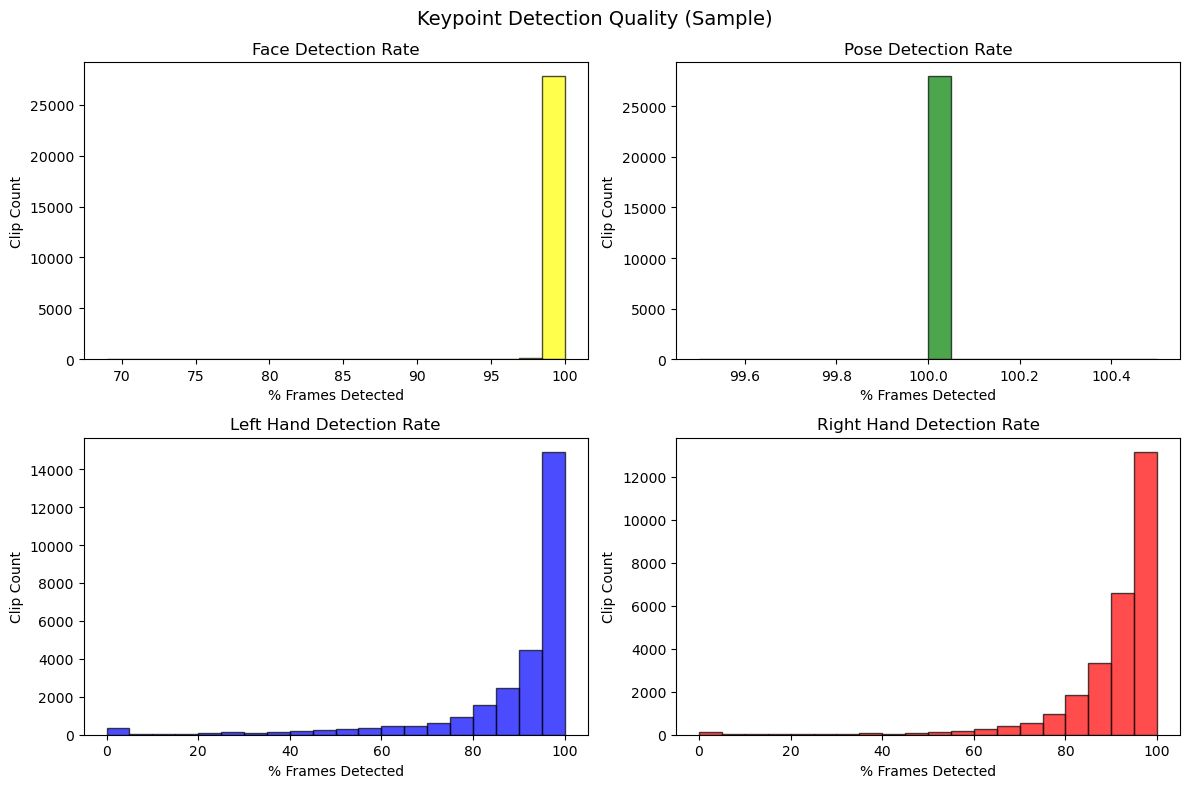


--- Potentially Problematic Clips ---

Found 204 clips with detection issues (in sample):


,file,issues,face_pct,pose_pct,lhand_pct,rhand_pct
0,-0N0jbyBW6g_0-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
1,-0yRaqY7nTE_0-5-rgb_front,no_hands,100.0,100.0,0.000000,16.666667
2,-1rM0t5FMiE_5-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
3,-70D86eMmIc_0-5-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
4,-8tIt1vEinQ_14-8-rgb_front,no_hands,100.0,100.0,0.000000,0.000000
5,-aZEs9_Vo6g_0-3-rgb_front,no_hands,100.0,100.0,0.763359,12.977099
6,-bLfarX5JXU_3-5-rgb_front,no_hands,100.0,100.0,7.291667,8.333333
7,-c5CKp2JWHE_12-5-rgb_front,no_hands,100.0,100.0,22.641509,5.660377
8,-djRbCXJLYo_10-5-rgb_front,no_hands,100.0,100.0,12.389381,17.699115
9,-djRbCXJLYo_9-5-rgb_front,no_hands,100.0,100.0,6.422018,8.256881



Quality analysis complete!


In [ ]:
## Step 6: Keypoint Quality Analysis

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Config ----
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
CSV_PATH = Path('..') / 'data' / 'how2sign_realigned_train_filtered.csv'
FAILED_CSV = Path('..') / 'data' / 'keypoint_extraction_failed.csv'
SAMPLE_SIZE = 1000  # number of files to deeply analyze

# ---- 1. Check failed extractions ----
print('=' * 60)
print('STEP 6: KEYPOINT QUALITY ANALYSIS')
print('=' * 60)

if FAILED_CSV.exists():
    failed_df = pd.read_csv(FAILED_CSV)
    print(f'\nFailed extractions: {len(failed_df)}')
    if len(failed_df) > 0:
        print('\nFailure breakdown:')
        print(failed_df['error'].value_counts())
        print('\nSample failed clips:')
        display(failed_df.head(10))
else:
    print('\nNo failed extractions file found - all clips likely succeeded!')

# ---- 2. Count extracted files ----
keypoint_files = list(KEYPOINT_DIR.glob('*.npz'))
df = pd.read_csv(CSV_PATH, sep='\t')

print(f'\n--- File Counts ---')
print(f'Total clips in CSV: {len(df)}')
print(f'Keypoint files extracted: {len(keypoint_files)}')
print(f'Missing: {len(df) - len(keypoint_files)}')

# ---- 3. Analyze keypoint statistics from sample ----
print(f'\n--- Analyzing {min(SAMPLE_SIZE, len(keypoint_files))} sample files ---')

sample_files = keypoint_files[:SAMPLE_SIZE]
stats = {
    'num_frames': [],
    'face_detected_pct': [],
    'pose_detected_pct': [],
    'left_hand_detected_pct': [],
    'right_hand_detected_pct': [],
    'file_size_mb': []
}

for kp_file in sample_files:
    data = np.load(kp_file)
    keypoints = data['keypoints']
    mask = data['mask']
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    
    T, N, _ = keypoints.shape
    stats['num_frames'].append(T)
    stats['file_size_mb'].append(kp_file.stat().st_size / (1024 * 1024))
    
    # Split mask by landmark type
    face_len = len(face_idx)
    pose_len = len(pose_idx)
    
    face_mask = mask[:, :face_len]
    pose_mask = mask[:, face_len:face_len + pose_len]
    lhand_mask = mask[:, face_len + pose_len:face_len + pose_len + 21]
    rhand_mask = mask[:, face_len + pose_len + 21:face_len + pose_len + 42]
    
    # Calculate detection percentage (% of frames where at least 1 landmark detected)
    stats['face_detected_pct'].append(100 * (face_mask.sum(axis=1) > 0).mean())
    stats['pose_detected_pct'].append(100 * (pose_mask.sum(axis=1) > 0).mean())
    stats['left_hand_detected_pct'].append(100 * (lhand_mask.sum(axis=1) > 0).mean())
    stats['right_hand_detected_pct'].append(100 * (rhand_mask.sum(axis=1) > 0).mean())

# Summary statistics
print('\nFrame count per clip:')
print(f'  Mean: {np.mean(stats["num_frames"]):.1f}')
print(f'  Median: {np.median(stats["num_frames"]):.1f}')
print(f'  Min: {np.min(stats["num_frames"])}')
print(f'  Max: {np.max(stats["num_frames"])}')

print('\nFile size per clip (MB):')
print(f'  Mean: {np.mean(stats["file_size_mb"]):.2f}')
print(f'  Median: {np.median(stats["file_size_mb"]):.2f}')
print(f'  Total (estimated for all clips): {np.mean(stats["file_size_mb"]) * len(keypoint_files) / 1024:.2f} GB')

print('\nDetection rates (% of frames with landmarks detected):')
print(f'  Face: {np.mean(stats["face_detected_pct"]):.1f}%')
print(f'  Pose: {np.mean(stats["pose_detected_pct"]):.1f}%')
print(f'  Left Hand: {np.mean(stats["left_hand_detected_pct"]):.1f}%')
print(f'  Right Hand: {np.mean(stats["right_hand_detected_pct"]):.1f}%')

# ---- 4. Visualize detection rates ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Keypoint Detection Quality (Sample)', fontsize=14)

axes[0, 0].hist(stats['face_detected_pct'], bins=20, edgecolor='black', color='yellow', alpha=0.7)
axes[0, 0].set_title('Face Detection Rate')
axes[0, 0].set_xlabel('% Frames Detected')
axes[0, 0].set_ylabel('Clip Count')

axes[0, 1].hist(stats['pose_detected_pct'], bins=20, edgecolor='black', color='green', alpha=0.7)
axes[0, 1].set_title('Pose Detection Rate')
axes[0, 1].set_xlabel('% Frames Detected')
axes[0, 1].set_ylabel('Clip Count')

axes[1, 0].hist(stats['left_hand_detected_pct'], bins=20, edgecolor='black', color='blue', alpha=0.7)
axes[1, 0].set_title('Left Hand Detection Rate')
axes[1, 0].set_xlabel('% Frames Detected')
axes[1, 0].set_ylabel('Clip Count')

axes[1, 1].hist(stats['right_hand_detected_pct'], bins=20, edgecolor='black', color='red', alpha=0.7)
axes[1, 1].set_title('Right Hand Detection Rate')
axes[1, 1].set_xlabel('% Frames Detected')
axes[1, 1].set_ylabel('Clip Count')

plt.tight_layout()
plt.show()

# ---- 5. Check for problematic clips ----
print('\n--- Potentially Problematic Clips ---')
problematic = []
for i, kp_file in enumerate(sample_files):
    issues = []
    if stats['face_detected_pct'][i] < 50:
        issues.append('low_face')
    if stats['pose_detected_pct'][i] < 50:
        issues.append('low_pose')
    if stats['left_hand_detected_pct'][i] < 30 and stats['right_hand_detected_pct'][i] < 30:
        issues.append('no_hands')
    
    if issues:
        problematic.append({
            'file': kp_file.stem,
            'issues': ','.join(issues),
            'face_pct': stats['face_detected_pct'][i],
            'pose_pct': stats['pose_detected_pct'][i],
            'lhand_pct': stats['left_hand_detected_pct'][i],
            'rhand_pct': stats['right_hand_detected_pct'][i]
        })

if problematic:
    prob_df = pd.DataFrame(problematic)
    print(f'\nFound {len(prob_df)} clips with detection issues (in sample):')
    display(prob_df.head(10))
else:
    print('\nNo significant detection issues found in sample!')

print('\n' + '=' * 60)
print('Quality analysis complete!')
print('=' * 60)

In [23]:
## Step 7: Preprocessing & Normalization

from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Config ----
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'train'
OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / 'train'
CSV_PATH = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3  # frames - forward fill gaps ≤ this, mask gaps > this

print('=' * 60)
print('STEP 7: PREPROCESSING & NORMALIZATION')
print('=' * 60)

# ---- Helper Functions ----

def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    """
    Forward-fill NaN gaps ≤ max_gap frames.
    Longer gaps remain as 0 with mask=0.
    
    Args:
        keypoints: (T, N, 3) array
        mask: (T, N) array
        max_gap: max frames to forward-fill
    
    Returns:
        filled_keypoints, updated_mask
    """
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):  # For each landmark
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:  # Valid landmark
                # Check if we just exited a gap
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        # Forward-fill this short gap
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1  # Mark as valid (filled)
                    # Else: gap > max_gap, leave as 0 with mask=0
                    gap_start = None
                
                last_valid_idx = t
            else:  # Invalid landmark
                if gap_start is None:
                    gap_start = t
        
        # Handle gap at end of sequence
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    """
    Center keypoints by body center and normalize by shoulder width.
    Forward-fills normalization parameters when shoulders are missing to ensure consistency.
    
    Args:
        keypoints: (T, N, 3) array
        mask: (T, N) array
        face_idx: list of face landmark indices (to determine split)
        pose_idx: list of pose landmark indices (to find shoulders)
    
    Returns:
        normalized_keypoints
    """
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    # Pose landmarks are after face landmarks
    face_len = len(face_idx)
    pose_start = face_len
    
    # Shoulder indices in pose_idx are 11 (left) and 12 (right)
    # Find their positions in the keypoints array
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        print('Warning: Shoulders not found in pose_idx, skipping normalization')
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    # Forward-fill normalization parameters
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        # Try to get normalization params from current frame
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]  # x, y only
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            # Update last valid params if valid
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                # Invalid shoulder width, don't use this frame
                body_center = None
                shoulder_width = None
        
        # If current frame has no shoulders, use last valid params
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        # Apply normalization if we have valid params
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    # Center x, y
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    # Normalize by shoulder width
                    normalized[t, n, :2] /= shoulder_width
                    # Keep z as-is (depth is relative anyway)
    
    return normalized


# ---- Main Preprocessing ----

df = pd.read_csv(CSV_PATH, sep='\t')
keypoint_files = list(KEYPOINT_DIR.glob('*.npz'))

# Filter to only process files in the final CSV
sentence_names_in_csv = set(df['SENTENCE_NAME'].astype(str))
keypoint_files = [f for f in keypoint_files if f.stem in sentence_names_in_csv]

print(f'\nPreprocessing {len(keypoint_files)} keypoint files...')
print(f'Forward-fill gaps: ≤ {FORWARD_FILL_MAX_GAP} frames')
print(f'Mask gaps: > {FORWARD_FILL_MAX_GAP} frames')

processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    # Load raw keypoints
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()  # (T, N, 3)
    mask = data['mask'].copy()  # (T, N)
    
    # Extract metadata
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    # Step 1: Forward-fill short gaps, mask long gaps
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    
    # Step 2: Center and normalize by body size
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    
    # Step 3: Replace any remaining NaN with 0 (shouldn't be any, but safety check)
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    # Save preprocessed keypoints
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'\n--- Preprocessing Complete ---')
print(f'Processed: {processed_count}')
print(f'Skipped (already exists): {skipped_count}')
print(f'Output directory: {OUT_DIR.resolve()}')
print()
print('Preprocessing applied:')
print('  1. Forward-fill: Gaps ≤ 3 frames filled with previous valid value')
print('  2. Masking: Gaps > 3 frames kept as 0 with mask=0')
print('  3. Centering: Subtracted body center (midpoint of shoulders)')
print('  4. Normalization: Scaled by shoulder width')
print('  5. Normalization params forward-filled for frames with missing shoulders')
print()
print('=' * 60)

STEP 7: PREPROCESSING & NORMALIZATION

Preprocessing 25921 keypoint files...
Forward-fill gaps: ≤ 3 frames
Mask gaps: > 3 frames


Preprocessing: 100%|██████████| 25921/25921 [20:28<00:00, 21.09it/s]  


--- Preprocessing Complete ---
Processed: 25921
Skipped (already exists): 0
Output directory: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\train

Preprocessing applied:
  1. Forward-fill: Gaps ≤ 3 frames filled with previous valid value
  2. Masking: Gaps > 3 frames kept as 0 with mask=0
  3. Centering: Subtracted body center (midpoint of shoulders)
  4. Normalization: Scaled by shoulder width
  5. Normalization params forward-filled for frames with missing shoulders



SANITY CHECK: Preprocessed Keypoints

Analyzed 10 files
Total valid keypoints: 223,595

Coordinate statistics (after normalization):
  X: mean=-0.103583, std=0.2897, min=-1.2376, max=1.5271
  Y: mean=-0.321058, std=0.9402, min=-2.1903, max=3.7164
  Z: mean=-0.062454, std=0.1848, min=-1.2051, max=0.1863

✅ Expected: X and Y centered near 0 (body center removed)
✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)
✅ Expected: Z values remain in original MediaPipe scale


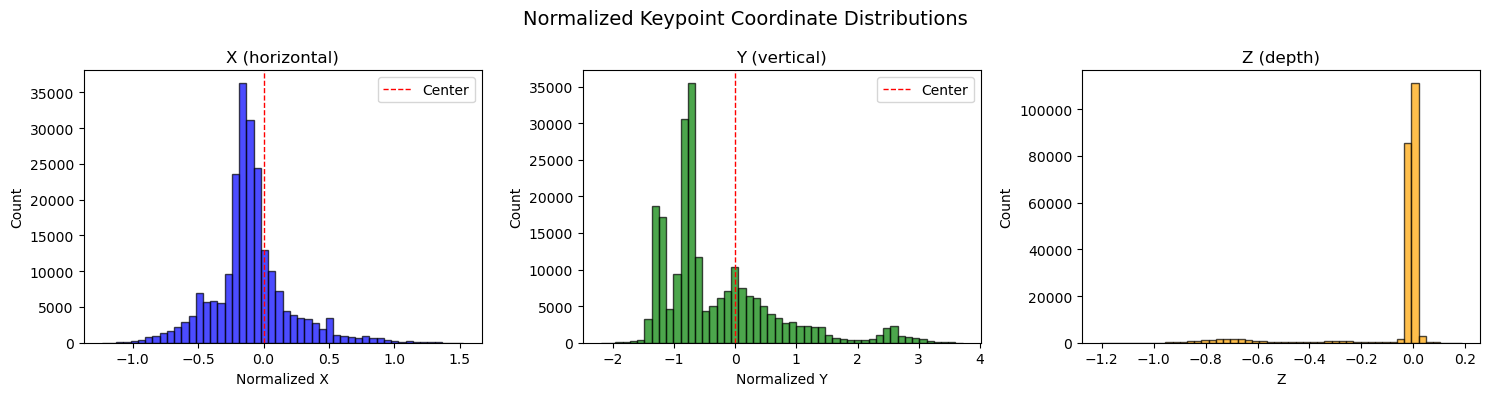

In [2]:
## Quick Sanity Check: Verify Preprocessed Keypoints

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PREPROCESSED_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / 'train'
SAMPLE_SIZE = 10

print('=' * 60)
print('SANITY CHECK: Preprocessed Keypoints')
print('=' * 60)

# Load sample files
preprocessed_files = list(PREPROCESSED_DIR.glob('*.npz'))[:SAMPLE_SIZE]

all_coords = []
for pf in preprocessed_files:
    data = np.load(pf)
    keypoints = data['keypoints']
    mask = data['mask']
    
    # Extract only valid (non-masked) coordinates
    valid_coords = keypoints[mask == 1]
    all_coords.append(valid_coords)

all_coords = np.concatenate(all_coords, axis=0)

print(f'\nAnalyzed {SAMPLE_SIZE} files')
print(f'Total valid keypoints: {len(all_coords):,}')
print()
print('Coordinate statistics (after normalization):')
print(f'  X: mean={all_coords[:, 0].mean():.6f}, std={all_coords[:, 0].std():.4f}, min={all_coords[:, 0].min():.4f}, max={all_coords[:, 0].max():.4f}')
print(f'  Y: mean={all_coords[:, 1].mean():.6f}, std={all_coords[:, 1].std():.4f}, min={all_coords[:, 1].min():.4f}, max={all_coords[:, 1].max():.4f}')
print(f'  Z: mean={all_coords[:, 2].mean():.6f}, std={all_coords[:, 2].std():.4f}, min={all_coords[:, 2].min():.4f}, max={all_coords[:, 2].max():.4f}')
print()
print('✅ Expected: X and Y centered near 0 (body center removed)')
print('✅ Expected: X and Y scaled by shoulder width (typically -2 to +2 range)')
print('✅ Expected: Z values remain in original MediaPipe scale')

# Visualize distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Normalized Keypoint Coordinate Distributions', fontsize=14)

axes[0].hist(all_coords[:, 0], bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('X (horizontal)')
axes[0].set_xlabel('Normalized X')
axes[0].set_ylabel('Count')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='Center')
axes[0].legend()

axes[1].hist(all_coords[:, 1], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Y (vertical)')
axes[1].set_xlabel('Normalized Y')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1, label='Center')
axes[1].legend()

axes[2].hist(all_coords[:, 2], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_title('Z (depth)')
axes[2].set_xlabel('Z')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('=' * 60)

In [4]:
## Process Val Split: Extract & Preprocess Keypoints

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
SPLIT = 'val'
CLIPS_DIR = Path(r'D:\How2Sign\val\val_rgb_front_clips')
CSV_PATH = Path('..') / 'data' / 'how2sign_val.csv'
RAW_OUT_DIR = Path('..') / 'data' / 'keypoints' / SPLIT
PREPROCESSED_OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / SPLIT
RAW_OUT_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Extraction config (EXACT same as train)
NUM_WORKERS = 4
TARGET_FPS = 20
OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3

# Landmark config (EXACT same as train)
mp_fm = mp.solutions.face_mesh
FACE_USE_LIPS = True
FACE_EYE_MODE = 'none'
FACE_USE_EYEBROWS = True
FACE_USE_NOSE = False
NOSE_MODE = 'none'
NOSE_MAX_POINTS = 4

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))
POSE_IDX = list(range(11, 25))

print('=' * 60)
print(f'PROCESSING {SPLIT.upper()} SPLIT')
print('=' * 60)
print(f'Face landmarks: {len(FACE_IDX)}')
print(f'Pose landmarks: {len(POSE_IDX)}')
print(f'Hand landmarks: 42 (21 each)')
print(f'Total per frame: {len(FACE_IDX) + len(POSE_IDX) + 42}')
print(f'Workers: {NUM_WORKERS}')

# ---- Helper Functions (same as train) ----

def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, overwrite, face_idx, pose_idx, refine_face):
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.npz'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))


def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1
                    gap_start = None
                last_valid_idx = t
            else:
                if gap_start is None:
                    gap_start = t
        
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    face_len = len(face_idx)
    pose_start = face_len
    
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                body_center = None
                shoulder_width = None
        
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    normalized[t, n, :2] /= shoulder_width
    
    return normalized


# ---- Step 1: Extract Raw Keypoints ----
print('\nStep 1: Extracting raw keypoints...')

df = pd.read_csv(CSV_PATH, sep='\t')
print(f'Total clips in CSV: {len(df)}')

failed_list = []
success_count = 0

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, RAW_OUT_DIR, TARGET_FPS, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'Extraction: {success_count} success, {len(failed_list)} failed')

# ---- Step 2: Preprocess & Normalize ----
print('\nStep 2: Preprocessing & normalizing...')

keypoint_files = list(RAW_OUT_DIR.glob('*.npz'))
processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = PREPROCESSED_OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()
    mask = data['mask'].copy()
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'Preprocessing: {processed_count} processed, {skipped_count} skipped')
print(f'\n✅ Val split complete!')
print(f'Raw keypoints: {RAW_OUT_DIR.resolve()}')
print(f'Preprocessed: {PREPROCESSED_OUT_DIR.resolve()}')
print('=' * 60)

PROCESSING VAL SPLIT
Face landmarks: 60
Pose landmarks: 14
Hand landmarks: 42 (21 each)
Total per frame: 116
Workers: 4

Step 1: Extracting raw keypoints...
Total clips in CSV: 1741


Extracting: 100%|██████████| 1741/1741 [00:00<00:00, 17868.37it/s]


Extraction: 1739 success, 2 failed

Step 2: Preprocessing & normalizing...


Preprocessing: 100%|██████████| 1739/1739 [00:00<00:00, 22570.96it/s]

Preprocessing: 0 processed, 1739 skipped

✅ Val split complete!
Raw keypoints: C:\My Projects\sign-language-bridge\data\keypoints\val
Preprocessed: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\val


In [5]:
## Process Test Split: Extract & Preprocess Keypoints

from pathlib import Path
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
SPLIT = 'test'
CLIPS_DIR = Path(r'D:\How2Sign\test\test_rgb_front_clips')
CSV_PATH = Path('..') / 'data' / 'how2sign_test.csv'
RAW_OUT_DIR = Path('..') / 'data' / 'keypoints' / SPLIT
PREPROCESSED_OUT_DIR = Path('..') / 'data' / 'keypoints_preprocessed' / SPLIT
RAW_OUT_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Extraction config (EXACT same as train)
NUM_WORKERS = 4
TARGET_FPS = 20
OVERWRITE = False
FORWARD_FILL_MAX_GAP = 3

# Landmark config (EXACT same as train)
mp_fm = mp.solutions.face_mesh
FACE_USE_LIPS = True
FACE_EYE_MODE = 'none'
FACE_USE_EYEBROWS = True
FACE_USE_NOSE = False
NOSE_MODE = 'none'
NOSE_MAX_POINTS = 4

def _idx(connection_set):
    return sorted({i for pair in connection_set for i in pair})

def _select_evenly(idx_list, k):
    if k is None or k >= len(idx_list): return idx_list
    if k <= 0: return []
    import numpy as _np
    sel = _np.linspace(0, len(idx_list) - 1, k)
    return [idx_list[int(round(i))] for i in sel]

REFINE_FACE_LANDMARKS = (FACE_EYE_MODE == 'iris')

face_parts = []
if FACE_USE_LIPS:
    face_parts += _idx(mp_fm.FACEMESH_LIPS)
if FACE_EYE_MODE == 'full':
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYE) + _idx(mp_fm.FACEMESH_RIGHT_EYE)
elif FACE_EYE_MODE == 'iris':
    face_parts += _idx(mp_fm.FACEMESH_IRISES)
if FACE_USE_EYEBROWS:
    face_parts += _idx(mp_fm.FACEMESH_LEFT_EYEBROW) + _idx(mp_fm.FACEMESH_RIGHT_EYEBROW)
nose_idx = []
if FACE_USE_NOSE and NOSE_MODE != 'none':
    nose_idx = _idx(mp_fm.FACEMESH_NOSE)
    if NOSE_MODE == 'reduced':
        nose_idx = _select_evenly(nose_idx, NOSE_MAX_POINTS)
    face_parts += nose_idx

FACE_IDX = sorted(set(face_parts))
POSE_IDX = list(range(11, 25))

print('=' * 60)
print(f'PROCESSING {SPLIT.upper()} SPLIT')
print('=' * 60)
print(f'Face landmarks: {len(FACE_IDX)}')
print(f'Pose landmarks: {len(POSE_IDX)}')
print(f'Hand landmarks: 42 (21 each)')
print(f'Total per frame: {len(FACE_IDX) + len(POSE_IDX) + 42}')
print(f'Workers: {NUM_WORKERS}')

# ---- Helper Functions (same as train) ----

def extract_clip_keypoints(row, clips_dir, out_dir, target_fps, overwrite, face_idx, pose_idx, refine_face):
    sentence_name = row.SENTENCE_NAME
    out_path = out_dir / f'{sentence_name}.npz'
    
    if out_path.exists() and not overwrite:
        return (sentence_name, True, None)
    
    clip_path = clips_dir / f'{sentence_name}.mp4'
    if not clip_path.exists():
        return (sentence_name, False, 'clip_missing')
    
    try:
        cap = cv2.VideoCapture(str(clip_path))
        if not cap.isOpened():
            cap.release()
            return (sentence_name, False, 'cv2_open_failed')
        
        src_fps = cap.get(cv2.CAP_PROP_FPS)
        frame_interval = 1
        if target_fps and src_fps and src_fps > 0:
            frame_interval = max(int(round(src_fps / target_fps)), 1)
        
        frames_kp = []
        frames_mask = []
        frame_idx = 0
        H = W = None
        
        mp_holistic = mp.solutions.holistic
        with mp_holistic.Holistic(
            static_image_mode=False,
            model_complexity=0,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5,
            refine_face_landmarks=refine_face,
        ) as holistic:
            
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                
                if frame_interval > 1 and (frame_idx % frame_interval) != 0:
                    frame_idx += 1
                    continue
                
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                res = holistic.process(rgb)
                
                H, W = frame.shape[:2]
                kp = []
                mask = []
                
                # Face
                if res.face_landmarks:
                    lms = res.face_landmarks.landmark
                    lms_len = len(lms)
                    for i in face_idx:
                        if i < lms_len:
                            lm = lms[i]
                            kp.extend([lm.x, lm.y, lm.z])
                            mask.append(1)
                        else:
                            kp.extend([float('nan')] * 3)
                            mask.append(0)
                else:
                    kp.extend([float('nan')] * (len(face_idx) * 3))
                    mask.extend([0] * len(face_idx))
                
                # Pose
                if res.pose_landmarks:
                    lms = res.pose_landmarks.landmark
                    for i in pose_idx:
                        lm = lms[i]
                        kp.extend([lm.x, lm.y, lm.z])
                        mask.append(1)
                else:
                    kp.extend([float('nan')] * (len(pose_idx) * 3))
                    mask.extend([0] * len(pose_idx))
                
                # Hands
                for hand_lms in [res.left_hand_landmarks, res.right_hand_landmarks]:
                    if hand_lms:
                        for lm in hand_lms.landmark:
                            kp.extend([lm.x, lm.y, lm.z])
                        mask.extend([1] * 21)
                    else:
                        kp.extend([float('nan')] * (21 * 3))
                        mask.extend([0] * 21)
                
                frames_kp.append(kp)
                frames_mask.append(mask)
                frame_idx += 1
        
        cap.release()
        
        if not frames_kp:
            return (sentence_name, False, 'no_frames')
        
        N = len(face_idx) + len(pose_idx) + 42
        arr = np.array(frames_kp, dtype=np.float32).reshape(len(frames_kp), N, 3)
        msk = np.array(frames_mask, dtype=np.uint8)
        np.savez(
            out_path,
            keypoints=arr,
            mask=msk,
            fps=np.array([float(src_fps)], dtype=np.float32) if (src_fps and src_fps > 0) else np.array([0.0], dtype=np.float32),
            image_size=np.array([H, W], dtype=np.int32) if (H and W) else np.array([0, 0], dtype=np.int32),
            face_idx=np.array(face_idx, dtype=np.int32),
            pose_idx=np.array(pose_idx, dtype=np.int32),
        )
        
        return (sentence_name, True, None)
    
    except Exception as e:
        return (sentence_name, False, str(e))


def forward_fill_short_gaps(keypoints, mask, max_gap=3):
    T, N, _ = keypoints.shape
    filled = keypoints.copy()
    new_mask = mask.copy()
    
    for n in range(N):
        gap_start = None
        last_valid_idx = None
        
        for t in range(T):
            if mask[t, n] == 1:
                if gap_start is not None:
                    gap_length = t - gap_start
                    if gap_length <= max_gap and last_valid_idx is not None:
                        for gap_t in range(gap_start, t):
                            filled[gap_t, n] = filled[last_valid_idx, n]
                            new_mask[gap_t, n] = 1
                    gap_start = None
                last_valid_idx = t
            else:
                if gap_start is None:
                    gap_start = t
        
        if gap_start is not None and last_valid_idx is not None:
            gap_length = T - gap_start
            if gap_length <= max_gap:
                for gap_t in range(gap_start, T):
                    filled[gap_t, n] = filled[last_valid_idx, n]
                    new_mask[gap_t, n] = 1
    
    return filled, new_mask


def center_and_normalize(keypoints, mask, face_idx, pose_idx):
    T, N, _ = keypoints.shape
    normalized = keypoints.copy()
    
    face_len = len(face_idx)
    pose_start = face_len
    
    pose_idx_array = np.array(pose_idx)
    left_shoulder_local = np.where(pose_idx_array == 11)[0]
    right_shoulder_local = np.where(pose_idx_array == 12)[0]
    
    if len(left_shoulder_local) == 0 or len(right_shoulder_local) == 0:
        return normalized
    
    left_shoulder_idx = pose_start + left_shoulder_local[0]
    right_shoulder_idx = pose_start + right_shoulder_local[0]
    
    last_body_center = None
    last_shoulder_width = None
    
    for t in range(T):
        body_center = None
        shoulder_width = None
        
        if mask[t, left_shoulder_idx] == 1 and mask[t, right_shoulder_idx] == 1:
            left_shoulder = keypoints[t, left_shoulder_idx, :2]
            right_shoulder = keypoints[t, right_shoulder_idx, :2]
            body_center = (left_shoulder + right_shoulder) / 2.0
            shoulder_width = np.linalg.norm(right_shoulder - left_shoulder)
            
            if shoulder_width > 1e-6:
                last_body_center = body_center
                last_shoulder_width = shoulder_width
            else:
                body_center = None
                shoulder_width = None
        
        if body_center is None and last_body_center is not None:
            body_center = last_body_center
            shoulder_width = last_shoulder_width
        
        if body_center is not None and shoulder_width is not None:
            for n in range(N):
                if mask[t, n] == 1:
                    normalized[t, n, 0] -= body_center[0]
                    normalized[t, n, 1] -= body_center[1]
                    normalized[t, n, :2] /= shoulder_width
    
    return normalized


# ---- Step 1: Extract Raw Keypoints ----
print('\nStep 1: Extracting raw keypoints...')

df = pd.read_csv(CSV_PATH, sep='\t')
print(f'Total clips in CSV: {len(df)}')

failed_list = []
success_count = 0

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
    futures = {
        executor.submit(
            extract_clip_keypoints,
            row, CLIPS_DIR, RAW_OUT_DIR, TARGET_FPS, OVERWRITE,
            FACE_IDX, POSE_IDX, REFINE_FACE_LANDMARKS
        ): idx
        for idx, row in enumerate(df.itertuples(index=False))
    }
    
    with tqdm(total=len(futures), desc='Extracting') as pbar:
        for future in as_completed(futures):
            sentence_name, success, error = future.result()
            if success:
                success_count += 1
            else:
                failed_list.append({'SENTENCE_NAME': sentence_name, 'error': error})
            pbar.update(1)

print(f'Extraction: {success_count} success, {len(failed_list)} failed')

# ---- Step 2: Preprocess & Normalize ----
print('\nStep 2: Preprocessing & normalizing...')

keypoint_files = list(RAW_OUT_DIR.glob('*.npz'))
processed_count = 0
skipped_count = 0

for kp_file in tqdm(keypoint_files, desc='Preprocessing'):
    out_path = PREPROCESSED_OUT_DIR / kp_file.name
    
    if out_path.exists() and not OVERWRITE:
        skipped_count += 1
        continue
    
    data = np.load(kp_file)
    keypoints = data['keypoints'].copy()
    mask = data['mask'].copy()
    face_idx = data['face_idx']
    pose_idx = data['pose_idx']
    fps = data['fps'] if 'fps' in data.files else np.array([20.0])
    image_size = data['image_size'] if 'image_size' in data.files else np.array([0, 0])
    
    keypoints, mask = forward_fill_short_gaps(keypoints, mask, max_gap=FORWARD_FILL_MAX_GAP)
    keypoints = center_and_normalize(keypoints, mask, face_idx.tolist(), pose_idx.tolist())
    keypoints = np.nan_to_num(keypoints, nan=0.0)
    
    np.savez_compressed(
        out_path,
        keypoints=keypoints,
        mask=mask,
        fps=fps,
        image_size=image_size,
        face_idx=face_idx,
        pose_idx=pose_idx,
    )
    
    processed_count += 1

print(f'Preprocessing: {processed_count} processed, {skipped_count} skipped')
print(f'\n✅ Test split complete!')
print(f'Raw keypoints: {RAW_OUT_DIR.resolve()}')
print(f'Preprocessed: {PREPROCESSED_OUT_DIR.resolve()}')
print('=' * 60)

PROCESSING TEST SPLIT
Face landmarks: 60
Pose landmarks: 14
Hand landmarks: 42 (21 each)
Total per frame: 116
Workers: 4

Step 1: Extracting raw keypoints...
Total clips in CSV: 2357


Extracting:   0%|          | 0/2357 [00:00<?, ?it/s]c:\ProgramData\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting: 100%|██████████| 2357/2357 [1:19:34<00:00,  2.03s/it]


Extraction: 2343 success, 14 failed

Step 2: Preprocessing & normalizing...


Preprocessing: 100%|██████████| 2343/2343 [01:55<00:00, 20.32it/s]

Preprocessing: 2343 processed, 0 skipped

✅ Test split complete!
Raw keypoints: C:\My Projects\sign-language-bridge\data\keypoints\test
Preprocessed: C:\My Projects\sign-language-bridge\data\keypoints_preprocessed\test


In [6]:
## Quick Verification: Val & Test Preprocessing

from pathlib import Path
import numpy as np
import pandas as pd

print('=' * 60)
print('VERIFICATION: Val & Test Preprocessing')
print('=' * 60)

# Check val
val_csv = pd.read_csv(Path('..') / 'data' / 'how2sign_val.csv', sep='\t')
val_preprocessed = list((Path('..') / 'data' / 'keypoints_preprocessed' / 'val').glob('*.npz'))

print(f'\nVAL SPLIT:')
print(f'  CSV rows: {len(val_csv)}')
print(f'  Preprocessed files: {len(val_preprocessed)}')
print(f'  Match: {"✅" if len(val_preprocessed) >= len(val_csv) * 0.95 else "❌"}')

# Check test
test_csv = pd.read_csv(Path('..') / 'data' / 'how2sign_test.csv', sep='\t')
test_preprocessed = list((Path('..') / 'data' / 'keypoints_preprocessed' / 'test').glob('*.npz'))

print(f'\nTEST SPLIT:')
print(f'  CSV rows: {len(test_csv)}')
print(f'  Preprocessed files: {len(test_preprocessed)}')
print(f'  Match: {"✅" if len(test_preprocessed) >= len(test_csv) * 0.95 else "❌"}')

# Verify landmark counts (sample 3 files from each)
print(f'\nLANDMARK VERIFICATION:')
for split, files in [('val', val_preprocessed[:3]), ('test', test_preprocessed[:3])]:
    if files:
        data = np.load(files[0])
        T, N, _ = data['keypoints'].shape
        print(f'  {split}: {N} landmarks per frame {"✅" if N == 116 else "❌ MISMATCH!"}')

# Quick sanity check on normalization (sample val)
if val_preprocessed:
    sample_coords = []
    for f in val_preprocessed[:5]:
        data = np.load(f)
        valid_coords = data['keypoints'][data['mask'] == 1]
        sample_coords.append(valid_coords)

    sample_coords = np.concatenate(sample_coords, axis=0)
    print(f'\nVAL NORMALIZATION CHECK:')
    print(f'  X mean: {sample_coords[:, 0].mean():.3f} (expect ≈0)')
    print(f'  Y mean: {sample_coords[:, 1].mean():.3f} (expect ≈0)')
    print(f'  X/Y in range [-2, +4]: {"✅" if sample_coords[:, :2].min() > -3 and sample_coords[:, :2].max() < 5 else "❌"}')

print('\n' + '=' * 60)
print('✅ Verification complete! Ready for Notebook 2.' if len(val_preprocessed) > 0 and len(test_preprocessed) > 0 else '⚠️ Check the resultsabove')
print('=' * 60)

VERIFICATION: Val & Test Preprocessing

VAL SPLIT:
  CSV rows: 1741
  Preprocessed files: 1739
  Match: ✅

TEST SPLIT:
  CSV rows: 2357
  Preprocessed files: 2343
  Match: ✅

LANDMARK VERIFICATION:
  val: 116 landmarks per frame ✅
  test: 116 landmarks per frame ✅

VAL NORMALIZATION CHECK:
  X mean: -0.114 (expect ≈0)
  Y mean: -0.064 (expect ≈0)
  X/Y in range [-2, +4]: ✅

✅ Verification complete! Ready for Notebook 2.


In [9]:
## Impact Analysis: Remove Sequences > 9.5 seconds

import pandas as pd
from pathlib import Path

# Load current filtered data
df = pd.read_csv(Path('..') / 'data' / '(final)_how2sign_train_filtered.csv', sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Current stats
current_examples = len(df)
current_hours = df['duration_sec'].sum() / 3600

# Filter to ≤ 9.0 seconds
NEW_MAX = 9.0
df_new = df[df['duration_sec'] <= NEW_MAX].copy()
df_removed = df[df['duration_sec'] > NEW_MAX].copy()

new_examples = len(df_new)
new_hours = df_new['duration_sec'].sum() / 3600
removed_examples = len(df_removed)
removed_hours = df_removed['duration_sec'].sum() / 3600

print('=' * 70)
print('IMPACT ANALYSIS: Remove Sequences > 9.0 seconds')
print('=' * 70)

print('\nCURRENT (1.3s - 13.6s):')
print(f'  Examples: {current_examples:,}')
print(f'  Total hours: {current_hours:.2f}h')
print(f'  Mean duration: {df["duration_sec"].mean():.2f}s')
print(f'  Median duration: {df["duration_sec"].median():.2f}s')

print('\nNEW (1.3s - 9.0s):')
print(f'  Examples: {new_examples:,} ({new_examples/current_examples*100:.1f}% retained)')
print(f'  Total hours: {new_hours:.2f}h ({new_hours/current_hours*100:.1f}% retained)')
print(f'  Mean duration: {df_new["duration_sec"].mean():.2f}s')
print(f'  Median duration: {df_new["duration_sec"].median():.2f}s')

print('\nREMOVED (>9.0s):')
print(f'  Examples: {removed_examples:,} ({removed_examples/current_examples*100:.1f}% of total)')
print(f'  Total hours: {removed_hours:.2f}h ({removed_hours/current_hours*100:.1f}% of total)')

print('\nDISTRIBUTION relative to inference (3-5s):')
print(f'  In range (3-5s): {((df_new["duration_sec"] >= 3) & (df_new["duration_sec"] <= 5)).sum() / len(df_new) * 100:.1f}%')
print(f'  Shorter (<3s): {(df_new["duration_sec"] < 3).sum() / len(df_new) * 100:.1f}%')
print(f'  Longer (5-9.0s): {(df_new["duration_sec"] > 5).sum() / len(df_new) * 100:.1f}%')

print('\n' + '=' * 70)
print('RECOMMENDATION:')
if removed_examples / current_examples < 0.15:
    print('✅ Low impact - cutting at 9.0s removes <15% of data, good trade-off!')
elif removed_examples / current_examples < 0.25:
    print('⚠️ Moderate impact - removes 15-25% of data, consider carefully')
else:
    print('❌ High impact - removes >25% of data, may hurt model performance')
print('=' * 70)

IMPACT ANALYSIS: Remove Sequences > 9.0 seconds

CURRENT (1.3s - 13.6s):
  Examples: 25,921
  Total hours: 41.08h
  Mean duration: 5.70s
  Median duration: 5.11s

NEW (1.3s - 9.0s):
  Examples: 21,567 (83.2% retained)
  Total hours: 27.85h (67.8% retained)
  Mean duration: 4.65s
  Median duration: 4.42s

REMOVED (>9.0s):
  Examples: 4,354 (16.8% of total)
  Total hours: 13.23h (32.2% of total)

DISTRIBUTION relative to inference (3-5s):
  In range (3-5s): 32.1%
  Shorter (<3s): 26.6%
  Longer (5-9.0s): 41.3%

RECOMMENDATION:
⚠️ Moderate impact - removes 15-25% of data, consider carefully


In [21]:
from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_train_filtered.csv'

# Same thresholds as val/test
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('TRAIN DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

TRAIN DATASET FILTERING
Original clips: 21567
Filtered clips: 19935 (92.4%)
Removed: 1632 (7.6%)
  - ≤1.3s: 0
  - >8.0s: 1632

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_train_filtered.csv


In [22]:
## Filter Val Dataset (same thresholds as train)

from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / 'how2sign_realigned_val.csv'
CSV_OUT = Path('..') / 'data' / '(final)_how2sign_val_filtered.csv'

# Same thresholds as train
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('VAL DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

VAL DATASET FILTERING
Original clips: 1741
Filtered clips: 1051 (60.4%)
Removed: 690 (39.6%)
  - ≤1.3s: 115
  - >8.0s: 575

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_val_filtered.csv


In [23]:
## Filter Test Dataset (same thresholds as train)

from pathlib import Path
import pandas as pd

CSV_IN = Path('..') / 'data' / 'how2sign_realigned_test.csv'
CSV_OUT = Path('..') / 'data' / '1(final)_how2sign_test_filtered.csv'

# Same thresholds as train
MIN_DURATION = 1.3
MAX_DURATION = 8.0

df = pd.read_csv(CSV_IN, sep='\t')
df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

# Filter
original_count = len(df)
df_filtered = df[(df['duration_sec'] > MIN_DURATION) & (df['duration_sec'] <= MAX_DURATION)].copy()
removed_count = original_count - len(df_filtered)

# Save
df_filtered.to_csv(CSV_OUT, sep='\t', index=False)

print('=' * 60)
print('TEST DATASET FILTERING')
print('=' * 60)
print(f'Original clips: {original_count}')
print(f'Filtered clips: {len(df_filtered)} ({len(df_filtered)/original_count*100:.1f}%)')
print(f'Removed: {removed_count} ({removed_count/original_count*100:.1f}%)')
print(f'  - ≤{MIN_DURATION}s: {(df["duration_sec"] <= MIN_DURATION).sum()}')
print(f'  - >{MAX_DURATION}s: {(df["duration_sec"] > MAX_DURATION).sum()}')
print(f'\nSaved: {CSV_OUT.resolve()}')
print('=' * 60)

TEST DATASET FILTERING
Original clips: 2357
Filtered clips: 1464 (62.1%)
Removed: 893 (37.9%)
  - ≤1.3s: 198
  - >8.0s: 695

Saved: C:\My Projects\sign-language-bridge\data\1(final)_how2sign_test_filtered.csv


Train data duration distribution:
count    19935.000000
mean         4.334456
std          1.824194
min          1.300000
25%          2.790000
50%          4.180000
75%          5.780000
max          8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 34.7%
% shorter than inference (<3s): 28.8%
% longer than inference (>5s): 36.5%


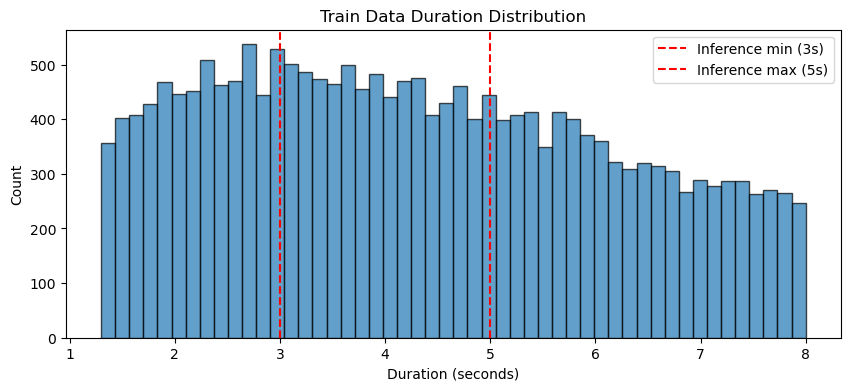

Val data duration distribution:
count    1051.000000
mean        4.370771
std         1.858983
min         1.310000
25%         2.730000
50%         4.270000
75%         5.925000
max         8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 31.9%
% shorter than inference (<3s): 30.4%
% longer than inference (>5s): 37.8%


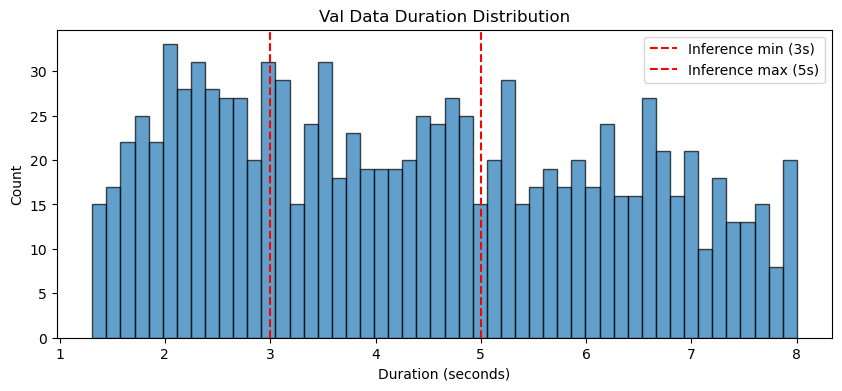

Test data duration distribution:
count    1464.000000
mean        4.295232
std         1.861895
min         1.310000
25%         2.700000
50%         4.155000
75%         5.800000
max         8.000000
Name: duration_sec, dtype: float64

% in inference range (3-5s): 32.9%
% shorter than inference (<3s): 30.5%
% longer than inference (>5s): 36.5%


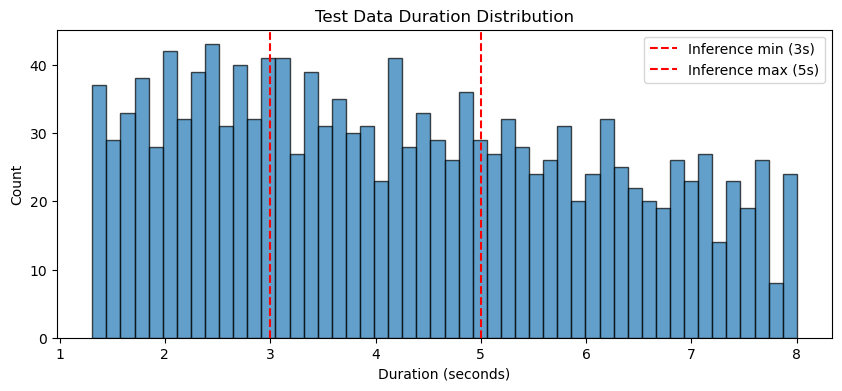

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
sets = ['train', 'val', 'test']

for split in sets:

    df = pd.read_csv(Path('..') / 'data' / f'(final)_how2sign_{split}_filtered.csv', sep='\t')
    df['duration_sec'] = df['END_REALIGNED'] - df['START_REALIGNED']

    print('=' * 60)
    print(f'{split.capitalize()} data duration distribution:')
    print(df['duration_sec'].describe(percentiles=[0.25, 0.5, 0.75]))
    print(f'\n% in inference range (3-5s): {((df["duration_sec"] >= 3) & (df["duration_sec"] <= 5)).sum() / len(df) * 100:.1f}%')
    print(f'% shorter than inference (<3s): {(df["duration_sec"] < 3).sum() / len(df) * 100:.1f}%')
    print(f'% longer than inference (>5s): {(df["duration_sec"] > 5).sum() / len(df) * 100:.1f}%')

    plt.figure(figsize=(10, 4))
    plt.hist(df['duration_sec'], bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(3, color='red', linestyle='--', label='Inference min (3s)')
    plt.axvline(5, color='red', linestyle='--', label='Inference max (5s)')
    plt.xlabel('Duration (seconds)')
    plt.ylabel('Count')
    plt.title(f'{split.capitalize()} Data Duration Distribution')
    plt.legend()
    plt.show()

In [28]:
# Overlay Keypoints on val Sample Clips

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ---- Config ----
CLIPS_DIR    = Path(r"D:\How2Sign\val\val_rgb_front_clips")
CSV_PATH     = Path('..') / 'data' / 'how2sign_val_filtered.csv'
KEYPOINT_DIR = Path('..') / 'data' / 'keypoints' / 'val'
KEYPOINT_EXT = 'npz'
OUT_DIR      = Path('..') / 'data' / 'overlays'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE  = 1
SAMPLE_NAMES = ["_5CV2fIG7qY_4-3-rgb_front"]
MAX_FRAMES   = None
TARGET_FPS   = None
OVERWRITE    = False

# Choose samples
if SAMPLE_NAMES is None:
    df = pd.read_csv(CSV_PATH, sep='\t')
    SAMPLE_NAMES = df['SENTENCE_NAME'].astype(str).head(int(SAMPLE_SIZE)).tolist()

print(f'Overlaying {len(SAMPLE_NAMES)} clips')
print(f'Keypoint dir: {KEYPOINT_DIR.resolve()}')
print(f'Output dir: {OUT_DIR.resolve()}')

POSE_CONNECTIONS = None
HAND_CONNECTIONS = None
try:
    import mediapipe as mp
    POSE_CONNECTIONS = mp.solutions.pose.POSE_CONNECTIONS
    HAND_CONNECTIONS = mp.solutions.hands.HAND_CONNECTIONS
except Exception:
    pass


def draw_points(frame, pts, mask, color, radius=2):
    for i, p in enumerate(pts):
        if mask is not None and mask[i] == 0:
            continue
        x, y = int(p[0] * frame.shape[1]), int(p[1] * frame.shape[0])
        if 0 <= x < frame.shape[1] and 0 <= y < frame.shape[0]:
            cv2.circle(frame, (x, y), radius, color, -1)


def draw_connections(frame, pts, mask, connections, color, thickness=2):
    for a, b in connections:
        if mask is not None and (mask[a] == 0 or mask[b] == 0):
            continue
        xa, ya = int(pts[a][0] * frame.shape[1]), int(pts[a][1] * frame.shape[0])
        xb, yb = int(pts[b][0] * frame.shape[1]), int(pts[b][1] * frame.shape[0])
        if 0 <= xa < frame.shape[1] and 0 <= ya < frame.shape[0] and 0 <= xb < frame.shape[1] and 0 <= yb < frame.shape[0]:
            cv2.line(frame, (xa, ya), (xb, yb), color, thickness)


for name in tqdm(SAMPLE_NAMES, desc='Overlay'):
    in_path  = CLIPS_DIR / f'{name}.mp4'
    out_path = OUT_DIR / f'{name}_overlay.mp4'
    kp_path  = KEYPOINT_DIR / f'{name}.{KEYPOINT_EXT}'

    if not in_path.exists():
        print(f'Skip missing clip: {name}')
        continue
    if not kp_path.exists():
        print(f'Skip missing keypoints: {name}')
        continue
    if out_path.exists() and not OVERWRITE:
        continue

    data = np.load(kp_path, allow_pickle=True)
    keypoints = data['keypoints']
    mask      = data['mask'] if 'mask' in data.files else None
    face_idx  = data['face_idx'] if 'face_idx' in data.files else None
    pose_idx  = data['pose_idx'] if 'pose_idx' in data.files else None

    T, N, _ = keypoints.shape
    
    # Dynamically determine split sizes from saved metadata
    face_len = int(len(face_idx)) if face_idx is not None else int(N - 14 - 42)
    pose_len = int(len(pose_idx)) if pose_idx is not None else 14
    hand_len = 21

    face_slice  = slice(0, face_len)
    pose_slice  = slice(face_len, face_len + pose_len)
    lhand_slice = slice(face_len + pose_len, face_len + pose_len + hand_len)
    rhand_slice = slice(face_len + pose_len + hand_len, face_len + pose_len + 2 * hand_len)

    cap = cv2.VideoCapture(str(in_path))
    if not cap.isOpened():
        print(f'Failed to open: {name}')
        cap.release()
        continue

    src_fps     = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
    width       = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frame_interval = 1
    out_fps = src_fps if src_fps and src_fps > 0 else 30
    if TARGET_FPS and src_fps and src_fps > 0:
        frame_interval = max(int(round(src_fps / TARGET_FPS)), 1)
        out_fps = float(src_fps) / frame_interval

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))
    if not writer.isOpened():
        out_path = OUT_DIR / f'{name}_overlay.avi'
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (width, height))

    if not writer.isOpened():
        print(f'Failed to open writer for: {name}')
        cap.release()
        continue

    frame_idx = 0
    written   = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_interval > 1 and (frame_idx % frame_interval) != 0:
            frame_idx += 1
            continue

        if frame_count and frame_count > 1:
            kp_idx = int(round(frame_idx * (T - 1) / max(frame_count - 1, 1)))
        else:
            kp_idx = min(frame_idx, T - 1)

        kp_frame   = keypoints[kp_idx]
        mask_frame = mask[kp_idx] if mask is not None else None

        # Face (yellow dots)
        draw_points(frame, kp_frame[face_slice], None if mask_frame is None else mask_frame[face_slice], (0, 255, 255), radius=1)

        # Pose (green dots + connections)
        pose_pts  = kp_frame[pose_slice]
        pose_mask = None if mask_frame is None else mask_frame[pose_slice]
        draw_points(frame, pose_pts, pose_mask, (0, 255, 0), radius=2)
        if POSE_CONNECTIONS is not None and pose_idx is not None:
            pose_map = {int(idx): i for i, idx in enumerate(pose_idx)}
            conns = [(pose_map[a], pose_map[b]) for a, b in POSE_CONNECTIONS if a in pose_map and b in pose_map]
            draw_connections(frame, pose_pts, pose_mask, conns, (0, 255, 0), thickness=1)

        # Left hand (blue) / Right hand (red)
        lpts  = kp_frame[lhand_slice]
        rpts  = kp_frame[rhand_slice]
        lmask = None if mask_frame is None else mask_frame[lhand_slice]
        rmask = None if mask_frame is None else mask_frame[rhand_slice]
        draw_points(frame, lpts, lmask, (255, 0, 0), radius=2)
        draw_points(frame, rpts, rmask, (0, 0, 255), radius=2)
        if HAND_CONNECTIONS is not None:
            draw_connections(frame, lpts, lmask, HAND_CONNECTIONS, (255, 0, 0), thickness=1)
            draw_connections(frame, rpts, rmask, HAND_CONNECTIONS, (0, 0, 255), thickness=1)

        writer.write(frame)
        written   += 1
        frame_idx += 1

        if MAX_FRAMES is not None and written >= int(MAX_FRAMES):
            break

    cap.release()
    writer.release()

    if written == 0:
        print(f'No frames written for: {name}')
    else:
        print(f'Wrote: {out_path.name} ({written} frames)')

print(f'Done. Overlays saved to: {OUT_DIR.resolve()}')

Overlaying 1 clips
Keypoint dir: C:\My Projects\sign-language-bridge\data\keypoints\val
Output dir: C:\My Projects\sign-language-bridge\data\overlays


Overlay: 100%|██████████| 1/1 [00:00<?, ?it/s]

Done. Overlays saved to: C:\My Projects\sign-language-bridge\data\overlays
